<a href="https://colab.research.google.com/github/EsterNevess/residencia-ia/blob/main/Aula_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
!pip install openai


In [34]:
from google.colab import userdata
from openai import OpenAI

OPENROUTER_API_KEY = userdata.get("OPENROUTER_API_KEY")

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

In [35]:
texto = "Inteligência artificial está transformando o mundo"

response = client.embeddings.create(
    model="openai/text-embedding-3-small",
    input=texto
)

vetor = response.data[0].embedding

print(f"Tipo do objeto: {type(vetor)}")
print(f"Número de dimensões (tamanho do vetor): {len(vetor)}")
print(f"Primeiros 10 números do vetor: {vetor[:10]}")

Tipo do objeto: <class 'list'>
Número de dimensões (tamanho do vetor): 1536
Primeiros 10 números do vetor: [0.03131103515625, 0.0146636962890625, -0.00110626220703125, 0.037261962890625, 0.036376953125, -0.032745361328125, 0.0031948089599609375, 0.0831298828125, -0.034423828125, 0.0010442733764648438]


In [36]:
import numpy as np


def distancia_euclidiana(embedding_a, embedding_b):
    vetor_a = np.array(embedding_a)
    vetor_b = np.array(embedding_b)

    return np.sqrt(np.sum((vetor_a - vetor_b) ** 2))

In [37]:
def distancia_cosseno(embedding_a, embedding_b):
    vetor_a = np.array(embedding_a)
    vetor_b = np.array(embedding_b)

    produto_escalar = np.dot(vetor_a, vetor_b)

    norma_a = np.linalg.norm(vetor_a)
    norma_b = np.linalg.norm(vetor_b)

    similaridade = produto_escalar / (norma_a * norma_b)

    return 1 - similaridade

In [38]:
embedding_a = [1, 0, 0]
embedding_b = [0, 1, 0]
embedding_c = [1, 0, 0]

print("--- Distância Euclidiana ---")
print(
    f"A x B: {distancia_euclidiana(embedding_a, embedding_b):.4f}"
)
print(
    f"A x C: {distancia_euclidiana(embedding_a, embedding_c):.4f}"
)
print(
    f"B x C: {distancia_euclidiana(embedding_b, embedding_c):.4f}"
)

print("\n--- Distância de Cosseno ---")
print(
    f"A x B: {distancia_cosseno(embedding_a, embedding_b):.4f}"
)
print(
    f"A x C: {distancia_cosseno(embedding_a, embedding_c):.4f}"
)
print(
    f"B x C: {distancia_cosseno(embedding_b, embedding_c):.4f}"
)

--- Distância Euclidiana ---
A x B: 1.4142
A x C: 0.0000
B x C: 1.4142

--- Distância de Cosseno ---
A x B: 1.0000
A x C: 0.0000
B x C: 1.0000


In [40]:
palavras = [
    "gato",
    "felino",
    "cachorro",
    "carro",
    "caminhão",
    "moto",
    "banana",
    "maçã",
    "goiaba",
]

embeddings_palavras = {}
for p in palavras:
    emb = get_embeddings(p)
    embeddings_palavras[p] = emb[0] if isinstance(emb, tuple) else emb

print("--- Comparação com Embeddings Reais ---\n")

print(
    f"Gato x Felino (Cosseno): {distancia_cosseno(embeddings_palavras['gato'], embeddings_palavras['felino']):.4f}"
)
print(
    f"Banana x Maçã (Cosseno): {distancia_cosseno(embeddings_palavras['banana'], embeddings_palavras['maçã']):.4f}"
)
print(
    f"Carro x Moto (Cosseno):   {distancia_cosseno(embeddings_palavras['carro'], embeddings_palavras['moto']):.4f}"
)

print("\n--- Categorias Diferentes ---")

print(
    f"Gato x Carro (Cosseno):   {distancia_cosseno(embeddings_palavras['gato'], embeddings_palavras['carro']):.4f}"
)
print(
    f"Gato x Banana (Cosseno):  {distancia_cosseno(embeddings_palavras['gato'], embeddings_palavras['banana']):.4f}"
)

--- Comparação com Embeddings Reais ---

Gato x Felino (Cosseno): 0.3636
Banana x Maçã (Cosseno): 0.6187
Carro x Moto (Cosseno):   0.5660

--- Categorias Diferentes ---
Gato x Carro (Cosseno):   0.6194
Gato x Banana (Cosseno):  0.7707


In [1]:
import numpy as np
import requests
from google.colab import userdata

OPENROUTER_API_KEY = userdata.get("OPENROUTER_API_KEY")

def distancia_euclidiana(embedding_a, embedding_b):
    a = np.array(embedding_a)
    b = np.array(embedding_b)
    return np.linalg.norm(a - b)

def distancia_cosseno(embedding_a, embedding_b):
    a = np.array(embedding_a)
    b = np.array(embedding_b)
    similaridade = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
    return 1 - similaridade

def get_embeddings(text):
    response = requests.post(
        "https://openrouter.ai/api/v1/embeddings",
        headers={
            "Authorization": f"Bearer {OPENROUTER_API_KEY}",
            "Content-Type": "application/json",
        },
        json={"model": "openai/text-embedding-3-small", "input": f"{text}"},
    )
    data = response.json()
    return data["data"][0]["embedding"]

emb_a = [1, 0, 0]
emb_b = [0, 1, 0]
emb_c = [1, 0, 0]

print("=== Teste com Vetores Simples ===")
print(f"Euclidiana (A e B): {distancia_euclidiana(emb_a, emb_b):.4f}")
print(f"Euclidiana (A e C): {distancia_euclidiana(emb_a, emb_c):.4f}")
print(f"Euclidiana (B e C): {distancia_euclidiana(emb_b, emb_c):.4f}")

print(f"\nCosseno (A e B): {distancia_cosseno(emb_a, emb_b):.4f}")
print(f"Cosseno (A e C): {distancia_cosseno(emb_a, emb_c):.4f}")
print(f"Cosseno (B e C): {distancia_cosseno(emb_b, emb_c):.4f}")

palavras = [
    "gato",
    "felino",
    "cachorro",
    "carro",
    "caminhão",
    "moto",
    "banana",
    "maçã",
    "goiaba",
]

print("\nObtendo embeddings da API...")
embeddings_dict = {p: get_embeddings(p) for p in palavras}

print("\n=== Comparações entre Palavras ===")
pares_para_testar = [
    ("gato", "felino"),
    ("gato", "carro"),
    ("banana", "maçã"),
    ("banana", "goiaba"),
]

for p1, p2 in pares_para_testar:
    v1, v2 = embeddings_dict[p1], embeddings_dict[p2]
    d_euc = distancia_euclidiana(v1, v2)
    d_cos = distancia_cosseno(v1, v2)
    print(f"[{p1} <-> {p2}] -> Euclidiana: {d_euc:.4f} | Cosseno: {d_cos:.4f}")

=== Teste com Vetores Simples ===
Euclidiana (A e B): 1.4142
Euclidiana (A e C): 0.0000
Euclidiana (B e C): 1.4142

Cosseno (A e B): 1.0000
Cosseno (A e C): 0.0000
Cosseno (B e C): 1.0000

Obtendo embeddings da API...

=== Comparações entre Palavras ===
[gato <-> felino] -> Euclidiana: 0.8531 | Cosseno: 0.3636
[gato <-> carro] -> Euclidiana: 1.1134 | Cosseno: 0.6194
[banana <-> maçã] -> Euclidiana: 1.1125 | Cosseno: 0.6188
[banana <-> goiaba] -> Euclidiana: 1.1642 | Cosseno: 0.6774


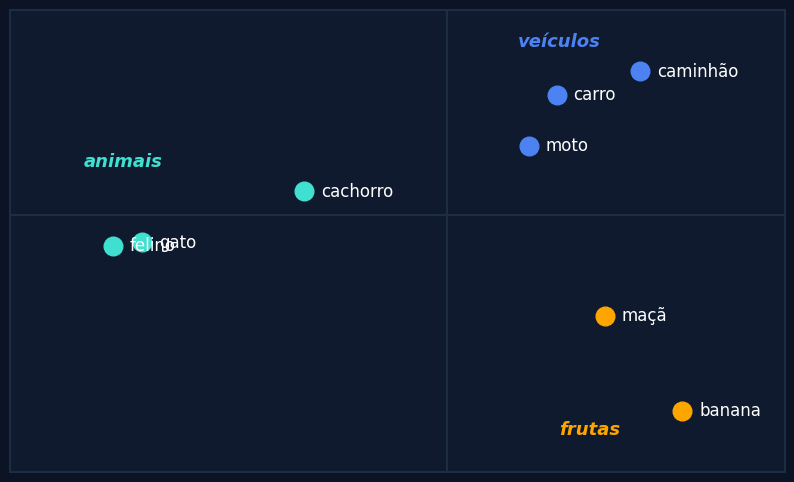

In [2]:
import matplotlib.pyplot as plt

import numpy as np

import requests

from google.colab import userdata

from sklearn.decomposition import PCA



OPENROUTER_API_KEY = userdata.get("OPENROUTER_API_KEY")





def get_embeddings(text):

    response = requests.post(

        "https://openrouter.ai/api/v1/embeddings",

        headers={

            "Authorization": f"Bearer {OPENROUTER_API_KEY}",

            "Content-Type": "application/json",

        },

        json={"model": "openai/text-embedding-3-small", "input": f"{text}"},

    )

    data = response.json()

    return data["data"][0]["embedding"]



palavras = [

    "gato",

    "felino",

    "cachorro",

    "carro",

    "caminhão",

    "moto",

    "maçã",

    "banana",

]



cores = [

    "#40E0D0",

    "#40E0D0",

    "#40E0D0",

    "#4D82F3",

    "#4D82F3",

    "#4D82F3",

    "#FFA500",

    "#FFA500",

]



vetores = [get_embeddings(p) for p in palavras]



pca = PCA(n_components=2)

vetores_2d = pca.fit_transform(vetores)



if np.mean(vetores_2d[3:6, 0]) < np.mean(vetores_2d[0:3, 0]):

    vetores_2d[:, 0] = -vetores_2d[:, 0]



if np.mean(vetores_2d[6:8, 1]) > np.mean(vetores_2d[0:3, 1]):

    vetores_2d[:, 1] = -vetores_2d[:, 1]



plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(10, 6), facecolor="#0B1325")

ax.set_facecolor("#0F1A2E")



plt.axhline(0, color="#1D2D44", linewidth=1.5, zorder=1)

plt.axvline(0, color="#1D2D44", linewidth=1.5, zorder=1)



plt.xticks([])

plt.yticks([])

plt.grid(False)



deslocamentos = {

    "gato": (12, -4),

    "felino": (12, -4),

    "cachorro": (12, -4),

    "carro": (12, -4),

    "caminhão": (12, -4),

    "moto": (12, -4),

    "maçã": (12, -4),

    "banana": (12, -4),

}



for i, palavra in enumerate(palavras):

    x, y = vetores_2d[i]

    plt.scatter(x, y, color=cores[i], s=180, zorder=3)



    dx, dy = deslocamentos.get(palavra, (12, -4))



    plt.annotate(

        palavra,

        (x, y),

        textcoords="offset points",

        xytext=(dx, dy),

        ha="left",

        color="#FFFFFF",

        fontsize=12,

        weight="medium",

    )



x_anim = np.min(vetores_2d[0:3, 0])

y_anim = np.max(vetores_2d[0:3, 1])

plt.annotate(

    "animais",

    xy=(x_anim - 0.05, y_anim + 0.08),

    color="#40E0D0",

    fontsize=13,

    fontstyle="italic",

    weight="bold",

)



x_veic = np.min(vetores_2d[3:6, 0])

y_veic = np.max(vetores_2d[3:6, 1])

plt.annotate(

    "veículos",

    xy=(x_veic - 0.02, y_veic + 0.08),

    color="#4D82F3",

    fontsize=13,

    fontstyle="italic",

    weight="bold",

)



x_frut = np.min(vetores_2d[6:8, 0])

y_frut = np.min(vetores_2d[6:8, 1])

plt.annotate(

    "frutas",

    xy=(x_frut - 0.08, y_frut - 0.08),

    color="#FFA500",

    fontsize=13,

    fontstyle="italic",

    weight="bold",

)



for spine in ax.spines.values():

    spine.set_color("#1D2D44")

    spine.set_linewidth(1.5)



plt.margins(0.18)

plt.show()

In [3]:
!pip install numpy pandas google-genai

In [9]:
import numpy as np
import pandas as pd
import re
from google.colab import userdata
from openai import OpenAI

api_key = userdata.get('OPENROUTER_API_KEY')

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=api_key,
)

def get_embedding(texto: str) -> list[float]:

    texto_limpo = texto.replace("\n", " ")
    resposta = client.embeddings.create(
        model="openai/text-embedding-3-small",
        input=texto_limpo
    )
    return resposta.data[0].embedding

In [10]:
def distancia_euclidiana(vec1: np.ndarray, vec2: np.ndarray) -> float:
    return float(np.linalg.norm(vec1 - vec2))

def similaridade_cosseno(vec1: np.ndarray, vec2: np.ndarray) -> float:
    norm_v1 = np.linalg.norm(vec1)
    norm_v2 = np.linalg.norm(vec2)
    if norm_v1 == 0 or norm_v2 == 0:
        return 0.0
    return float(np.dot(vec1, vec2) / (norm_v1 * norm_v2))

def distancia_cosseno(vec1: np.ndarray, vec2: np.ndarray) -> float:
    return float(1.0 - similaridade_cosseno(vec1, vec2))

def dividir_por_linhas(texto: str) -> list[str]:
    return [linha.strip() for linha in texto.split("\n") if linha.strip()]

def dividir_por_paragrafos(texto: str) -> list[str]:
    paragrafos = re.split(r'\n\s*\n', texto)
    return [p.strip().replace("\n", " ") for p in paragrafos if p.strip()]

def dividir_por_secoes(texto: str) -> list[str]:
    secoes = re.split(r'(?=\n#{1,3}\s)', texto)
    return [s.strip() for s in secoes if s.strip()]

def busca_semantica(query: str, trechos: list[str], top_k: int = 3) -> pd.DataFrame:
    vec_query = np.array(get_embedding(query), dtype=np.float32)

    resultados = []
    for idx, trecho in enumerate(trechos):
        vec_trecho = np.array(get_embedding(trecho), dtype=np.float32)

        sim_cos = similaridade_cosseno(vec_query, vec_trecho)
        dist_euc = distancia_euclidiana(vec_query, vec_trecho)
        dist_cos = distancia_cosseno(vec_query, vec_trecho)

        resultados.append({
            "ID": idx + 1,
            "Trecho": trecho[:100] + "..." if len(trecho) > 100 else trecho,
            "Similaridade Cosseno": round(sim_cos, 4),
            "Distância Euclidiana": round(dist_euc, 4),
            "Distância Cosseno": round(dist_cos, 4)
        })

    df = pd.DataFrame(resultados)
    df = df.sort_values(by="Similaridade Cosseno", ascending=False).reset_index(drop=True)
    return df.head(top_k)

In [11]:
with open("bioetica_e_ia.md", "r", encoding="utf-8") as f:
    doc1 = f.read()

with open("escrita_academica_ia.md", "r", encoding="utf-8") as f:
    doc2 = f.read()

with open("twitter_algoritmo.md", "r", encoding="utf-8") as f:
    doc3 = f.read()

texto_completo = doc1 + "\n\n" + doc2 + "\n\n" + doc3

pergunta = "O que é o diário de bordo da IA?"

print("=== TOP 3 POR LINHAS ===")
linhas = dividir_por_linhas(texto_completo)
display(busca_semantica(pergunta, linhas, top_k=3))

print("\n=== TOP 3 POR PARÁGRAFOS ===")
paragrafos = dividir_por_paragrafos(texto_completo)
display(busca_semantica(pergunta, paragrafos, top_k=3))

print("\n=== TOP 3 POR SEÇÕES ===")
secoes = dividir_por_secoes(texto_completo)
display(busca_semantica(pergunta, secoes, top_k=3))

=== TOP 3 POR LINHAS ===


,ID,Trecho,Similaridade Cosseno,Distância Euclidiana,Distância Cosseno
0,245,"Como uma fase adicional e não obrigatória, rec...",0.5676,0.9299,0.4324
1,259,## Declaração de uso de IA,0.5239,0.9760,0.4761
2,250,| Divulgação desne cessária | A IA atua em ...,0.5062,0.9938,0.4938



=== TOP 3 POR PARÁGRAFOS ===


,ID,Trecho,Similaridade Cosseno,Distância Euclidiana,Distância Cosseno
0,204,"Como uma fase adicional e não obrigatória, rec...",0.5676,0.9299,0.4324
1,214,## Declaração de uso de IA,0.5239,0.9761,0.4761
2,203,## III. Refletindo sobre o processo de escrita...,0.4916,1.0084,0.5084



=== TOP 3 POR SEÇÕES ===


,ID,Trecho,Similaridade Cosseno,Distância Euclidiana,Distância Cosseno
0,37,## Declaração de uso de IA,0.5239,0.9760,0.4761
1,39,## Conflito de interesses\n\nhabilidades. A do...,0.4792,1.0208,0.5208
2,35,## III. Refletindo sobre o processo de escrita...,0.4620,1.0375,0.5380
